# SIR Model for Epidemic Dynamics

This notebook explores the classic SIR (Susceptible-Infected-Recovered) compartmental model for disease spread, including:

1. Model formulation and the basic reproduction number $R_0$
2. Equilibrium analysis
3. Numerical simulation with different integration schemes
4. Phase portrait visualization
5. Vaccination strategies and herd immunity
6. Economic cost optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sir_model import SIR
from integrators import ExplicitEuler, RK2, RK4, Integrator
from cost_analysis import compute_epidemic_cost, optimize_vaccination_rate, cost_sensitivity_analysis

## 1. The SIR Model

The SIR model divides a population of size $N$ into three compartments:

- **S (Susceptible)**: individuals who can become infected
- **I (Infected)**: individuals who are currently infected and infectious
- **R (Recovered)**: individuals who have recovered and are immune

The dynamics are governed by:

$$
\begin{aligned}
\frac{dS}{dt} &= -\frac{\alpha S I}{N} - v S - d S + d N \\
\frac{dI}{dt} &= \frac{\alpha S I}{N} - (r + d) I \\
\frac{dR}{dt} &= r I - d R + v S
\end{aligned}
$$

where:
- $\alpha$ = infection rate
- $r$ = recovery rate
- $v$ = vaccination rate
- $d$ = death rate (= birth rate for constant population)

## 2. Basic Reproduction Number $R_0$

The **basic reproduction number** $R_0$ is the average number of secondary infections caused by a single infected individual in a fully susceptible population:

$$R_0 = \frac{\alpha}{r + d}$$

- $R_0 > 1$: Epidemic will spread
- $R_0 < 1$: Epidemic will die out
- $R_0 = 1$: Threshold for endemic equilibrium

In [2]:
# Create SIR model with typical parameters
sir = SIR(alpha=0.3, recovery_rate=0.1, vaccination_rate=0, death_rate=0)

r0 = sir.basic_reproduction_number()
print(f"Basic reproduction number R₀ = {r0:.2f}")
print(f"Interpretation: Each infected person infects {r0:.1f} others on average")

Basic reproduction number R₀ = 3.00
Interpretation: Each infected person infects 3.0 others on average


In [3]:
# Examples of R₀ for different diseases
diseases = {
    'Measles': SIR(alpha=0.9, recovery_rate=0.07),
    'Influenza': SIR(alpha=0.3, recovery_rate=0.2),
    'COVID-19 (original)': SIR(alpha=0.4, recovery_rate=0.14),
    'Common cold': SIR(alpha=0.2, recovery_rate=0.14)
}

print("Disease R₀ values:")
print("-" * 40)
for name, model in diseases.items():
    print(f"{name:25s}: R₀ = {model.basic_reproduction_number():.2f}")

Disease R₀ values:
----------------------------------------
Measles                  : R₀ = 12.86
Influenza                : R₀ = 1.50
COVID-19 (original)      : R₀ = 2.86
Common cold              : R₀ = 1.43


## 3. Equilibrium Analysis

### Disease-Free Equilibrium (DFE)
When $I = 0$, the system reaches a stable state with no infection: $(S^*, I^*, R^*) = (N, 0, 0)$

### Endemic Equilibrium
When $R_0 > 1$, the disease persists at a stable non-zero level:
$$S^* = \frac{N}{R_0}$$

In [4]:
# Analyze equilibria
sir = SIR(alpha=0.3, recovery_rate=0.1, death_rate=0.01)
N = 1000

r0 = sir.basic_reproduction_number()
print(f"R₀ = {r0:.2f}")

dfe = sir.disease_free_equilibrium(N)
print(f"\nDisease-free equilibrium: S={dfe[0]:.0f}, I={dfe[1]:.0f}, R={dfe[2]:.0f}")

try:
    endemic = sir.endemic_equilibrium(N)
    print(f"Endemic equilibrium: S={endemic[0]:.1f}, I={endemic[1]:.1f}, R={endemic[2]:.1f}")
    print(f"\nAt endemic equilibrium:")
    print(f"  - {endemic[0]/N*100:.1f}% susceptible")
    print(f"  - {endemic[1]/N*100:.1f}% infected")
    print(f"  - {endemic[2]/N*100:.1f}% recovered")
except ValueError as e:
    print(f"No endemic equilibrium: {e}")

R₀ = 2.73

Disease-free equilibrium: S=1000, I=0, R=0
Endemic equilibrium: S=366.7, I=57.6, R=575.8

At endemic equilibrium:
  - 36.7% susceptible
  - 5.8% infected
  - 57.6% recovered


## 4. Numerical Simulation

We compare different numerical integration schemes:
- **Explicit Euler**: First-order, simple but can be unstable
- **RK2 (Midpoint)**: Second-order, better accuracy
- **RK4**: Fourth-order, excellent balance of accuracy and efficiency
- **scipy.solve_ivp**: Adaptive step-size solver (reference)

In [5]:
# Simulation parameters
sir = SIR(alpha=0.3, recovery_rate=0.1, death_rate=0.01)
y0 = np.array([999, 1, 0])  # Initial: 999 susceptible, 1 infected, 0 recovered
t_max = 365  # One year
n_steps = 2000

# Run with different methods
methods = {
    'Euler': ExplicitEuler(sir),
    'RK2': RK2(sir),
    'RK4': RK4(sir)
}

results = {}
for name, method in methods.items():
    integrator = Integrator(method, y0, 0, t_max, n_steps)
    results[name] = integrator.integrate()
    
t = Integrator(methods['RK4'], y0, 0, t_max, n_steps).get_time()

# scipy reference
sol = solve_ivp(lambda t, y: sir(y, t), [0, t_max], y0, dense_output=True)
results['scipy'] = sol.sol(t).T

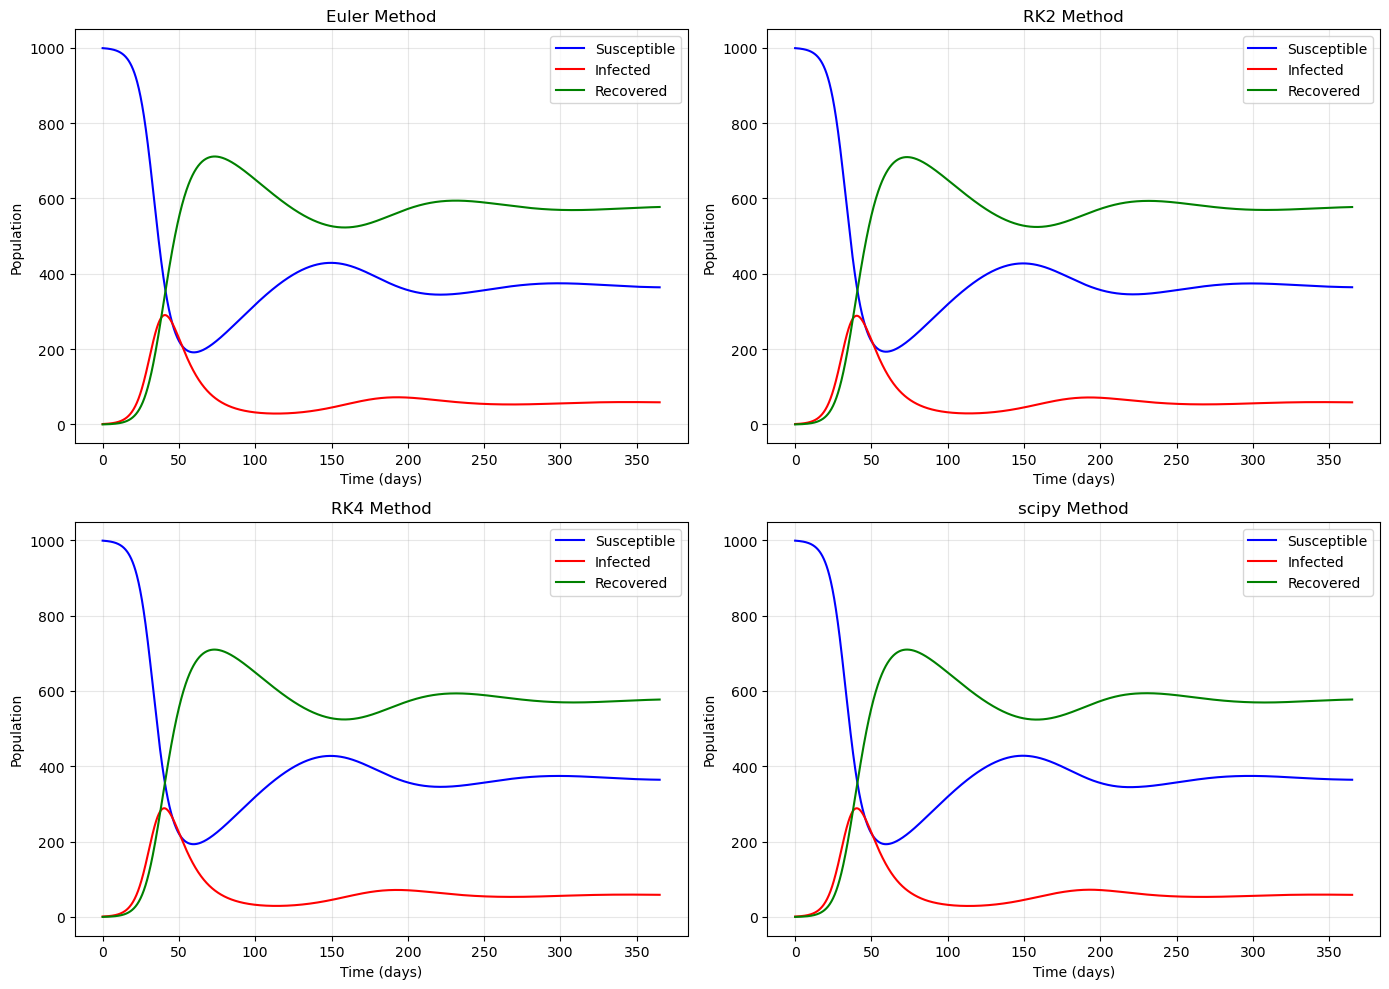

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, dynamics) in zip(axes.flat, results.items()):
    ax.plot(t, dynamics[:, 0], 'b-', label='Susceptible')
    ax.plot(t, dynamics[:, 1], 'r-', label='Infected')
    ax.plot(t, dynamics[:, 2], 'g-', label='Recovered')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Population')
    ax.set_title(f'{name} Method')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Compare final states
print("Final population distribution (S, I, R):")
print("-" * 50)
for name, dynamics in results.items():
    final = dynamics[-1]
    total = final.sum()
    pct = final / total * 100
    print(f"{name:8s}: S={pct[0]:5.1f}%, I={pct[1]:5.1f}%, R={pct[2]:5.1f}%")

Final population distribution (S, I, R):
--------------------------------------------------
Euler   : S= 36.4%, I=  5.9%, R= 57.7%
RK2     : S= 36.4%, I=  5.9%, R= 57.7%
RK4     : S= 36.4%, I=  5.9%, R= 57.7%
scipy   : S= 36.4%, I=  5.9%, R= 57.7%


## 5. Phase Portraits

Phase portraits show the trajectories in state space, revealing the system's dynamics without explicit time dependence.

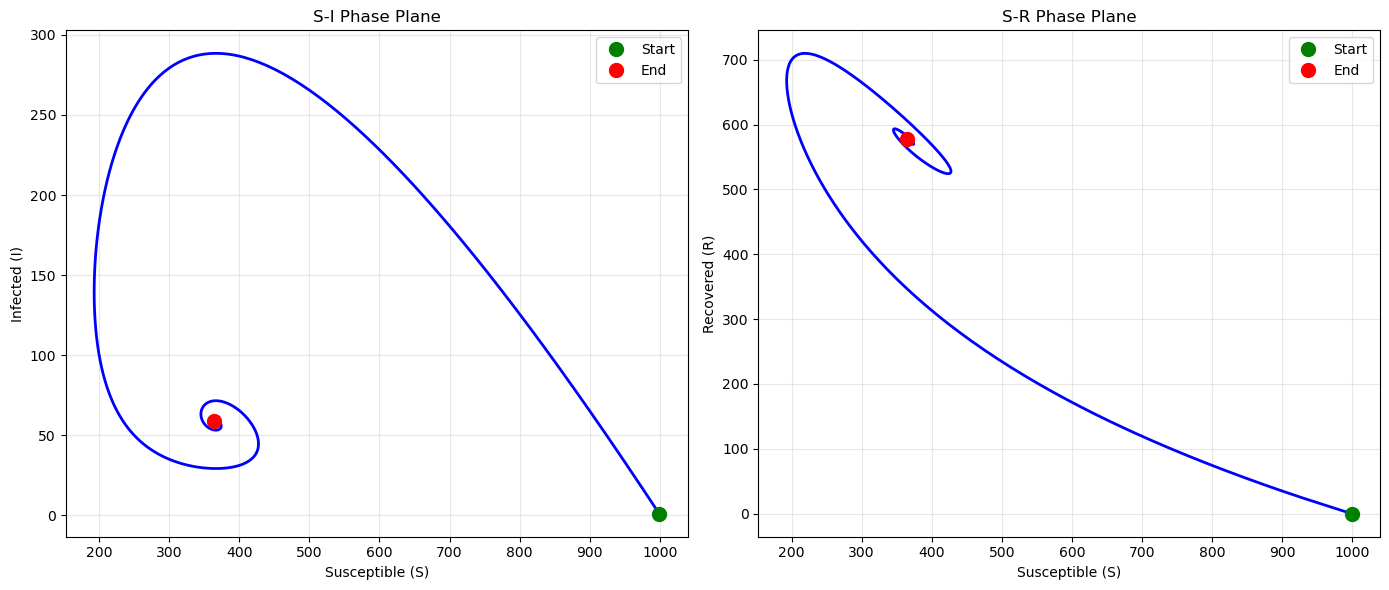

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dynamics = results['RK4']

# S-I phase plane
ax = axes[0]
ax.plot(dynamics[:, 0], dynamics[:, 1], 'b-', linewidth=2)
ax.plot(dynamics[0, 0], dynamics[0, 1], 'go', markersize=10, label='Start')
ax.plot(dynamics[-1, 0], dynamics[-1, 1], 'ro', markersize=10, label='End')
ax.set_xlabel('Susceptible (S)')
ax.set_ylabel('Infected (I)')
ax.set_title('S-I Phase Plane')
ax.legend()
ax.grid(True, alpha=0.3)

# S-R phase plane
ax = axes[1]
ax.plot(dynamics[:, 0], dynamics[:, 2], 'b-', linewidth=2)
ax.plot(dynamics[0, 0], dynamics[0, 2], 'go', markersize=10, label='Start')
ax.plot(dynamics[-1, 0], dynamics[-1, 2], 'ro', markersize=10, label='End')
ax.set_xlabel('Susceptible (S)')
ax.set_ylabel('Recovered (R)')
ax.set_title('S-R Phase Plane')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Vaccination Strategies and Herd Immunity

The **herd immunity threshold** is the fraction of the population that needs to be immune to prevent epidemic spread:

$$\text{HIT} = 1 - \frac{1}{R_0}$$

Vaccination reduces the effective susceptible population, potentially pushing $R_e$ below 1.

In [9]:
# Calculate herd immunity threshold
sir = SIR(alpha=0.3, recovery_rate=0.1)
r0 = sir.basic_reproduction_number()
hit = sir.herd_immunity_threshold()

print(f"R₀ = {r0:.2f}")
print(f"Herd immunity threshold = {hit*100:.1f}%")
print(f"\nTo prevent epidemic spread, {hit*100:.1f}% of the population needs immunity.")

R₀ = 3.00
Herd immunity threshold = 66.7%

To prevent epidemic spread, 66.7% of the population needs immunity.


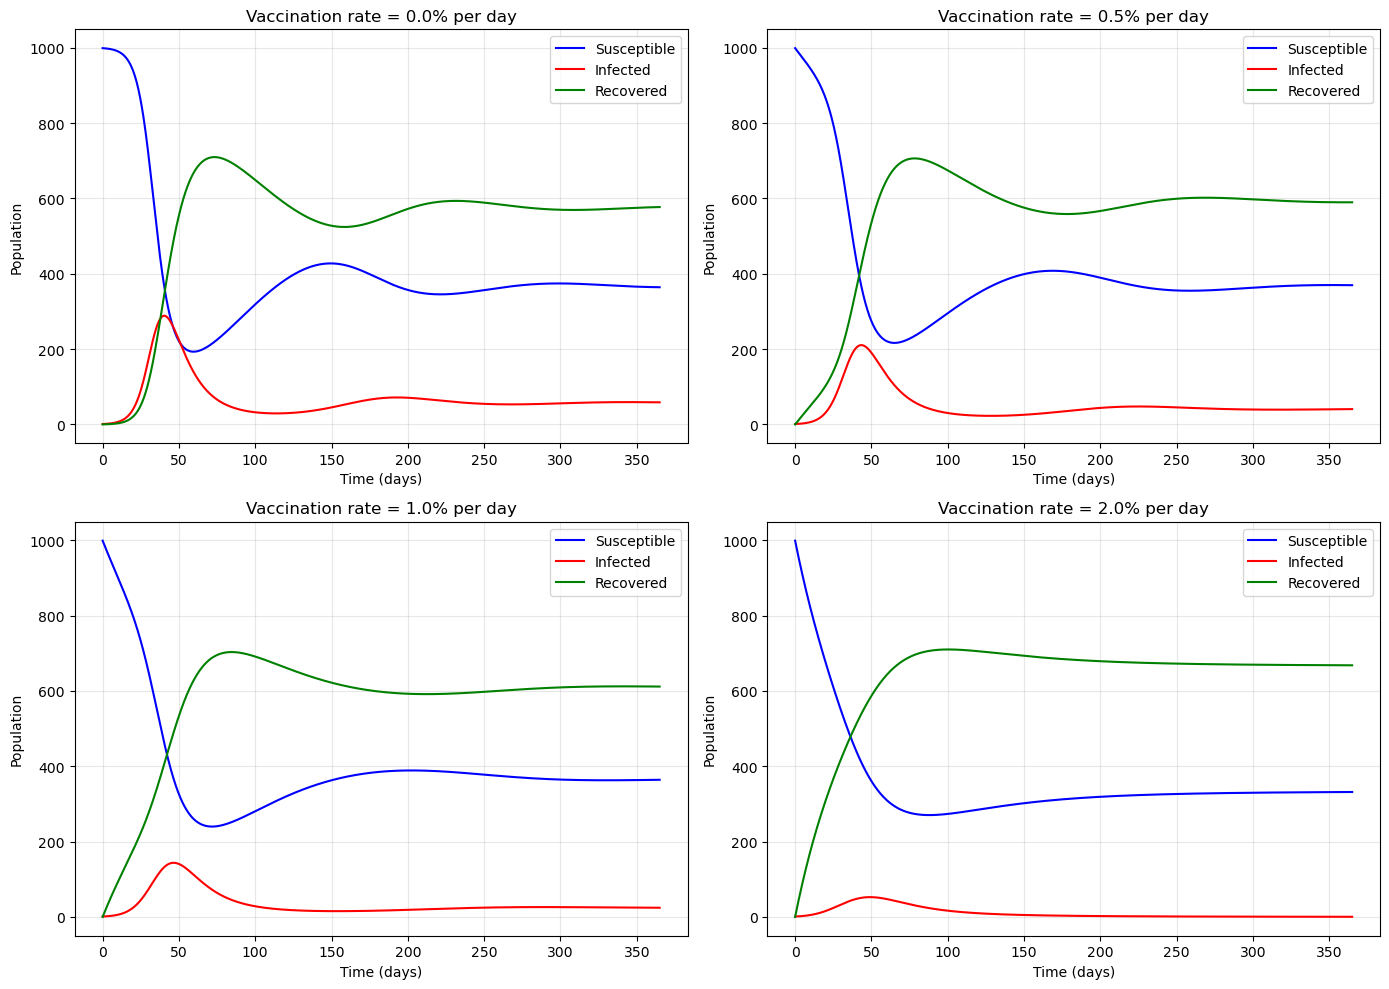

In [10]:
# Compare scenarios with different vaccination rates
vaccination_rates = [0, 0.005, 0.01, 0.02]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, v in zip(axes.flat, vaccination_rates):
    sir = SIR(alpha=0.3, recovery_rate=0.1, vaccination_rate=v, death_rate=0.01)
    method = RK4(sir)
    integrator = Integrator(method, y0, 0, t_max, n_steps)
    dynamics = integrator.integrate()
    t = integrator.get_time()
    
    ax.plot(t, dynamics[:, 0], 'b-', label='Susceptible')
    ax.plot(t, dynamics[:, 1], 'r-', label='Infected')
    ax.plot(t, dynamics[:, 2], 'g-', label='Recovered')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Population')
    ax.set_title(f'Vaccination rate = {v*100:.1f}% per day')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Economic Cost Optimization

Finding the optimal vaccination rate involves balancing:
- **Vaccination costs**: Cost of administering vaccines
- **Health costs**: Cost of infection (treatment, lost productivity)

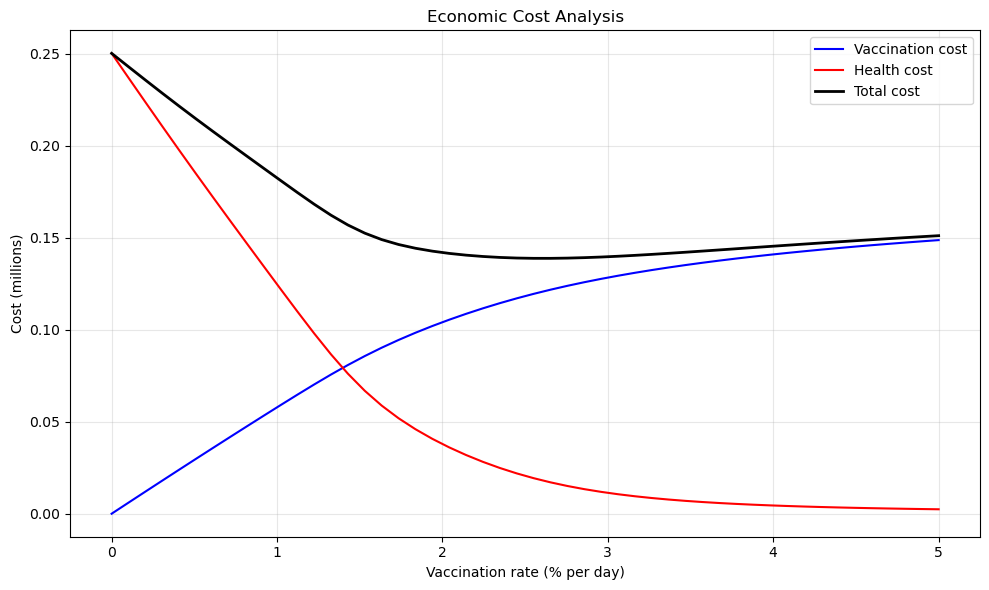

In [11]:
# Cost parameters
VACCINE_COST = 40  # Cost per vaccination
HEALTH_COST = 10   # Daily cost per infected person

# Analyze costs across vaccination rates
base_params = {'alpha': 0.3, 'recovery_rate': 0.1, 'death_rate': 0.01}
vaccination_rates = np.linspace(0, 0.05, 50)

analysis = cost_sensitivity_analysis(
    base_params, y0, t_max, n_steps,
    VACCINE_COST, HEALTH_COST, vaccination_rates
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(analysis['rates']*100, analysis['vaccine_costs']/1e6, 'b-', label='Vaccination cost')
ax.plot(analysis['rates']*100, analysis['health_costs']/1e6, 'r-', label='Health cost')
ax.plot(analysis['rates']*100, analysis['total_costs']/1e6, 'k-', linewidth=2, label='Total cost')

ax.set_xlabel('Vaccination rate (% per day)')
ax.set_ylabel('Cost (millions)')
ax.set_title('Economic Cost Analysis')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Find optimal vaccination rate
result = optimize_vaccination_rate(
    base_params, y0, t_max, n_steps,
    VACCINE_COST, HEALTH_COST,
    v_min=0, v_max=0.05
)

print(f"Optimal vaccination rate: {result['optimal_rate']*100:.3f}% per day")
print(f"Minimum total cost: ${result['min_cost']:,.0f}")

Optimal vaccination rate: 2.606% per day
Minimum total cost: $138,848


## 8. Sensitivity Analysis

How do changes in model parameters affect the epidemic dynamics?

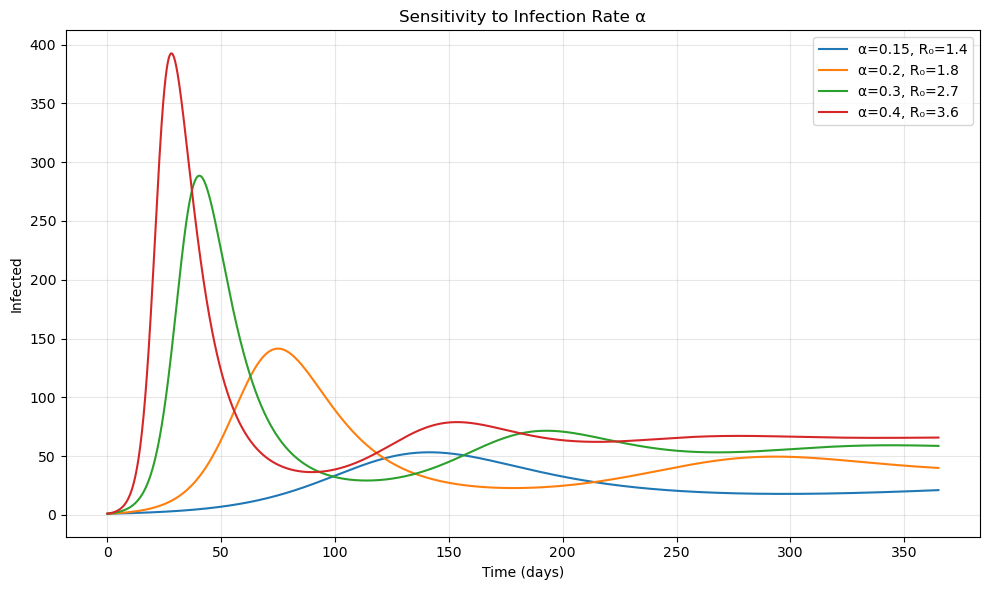

In [14]:
# Sensitivity to infection rate
alphas = [0.15, 0.2, 0.3, 0.4]

fig, ax = plt.subplots(figsize=(10, 6))

for alpha in alphas:
    sir = SIR(alpha=alpha, recovery_rate=0.1, death_rate=0.01)
    method = RK4(sir)
    integrator = Integrator(method, y0, 0, t_max, n_steps)
    dynamics = integrator.integrate()
    t = integrator.get_time()
    
    r0 = sir.basic_reproduction_number()
    ax.plot(t, dynamics[:, 1], label=f'α={alpha}, R₀={r0:.1f}')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Infected')
ax.set_title('Sensitivity to Infection Rate α')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

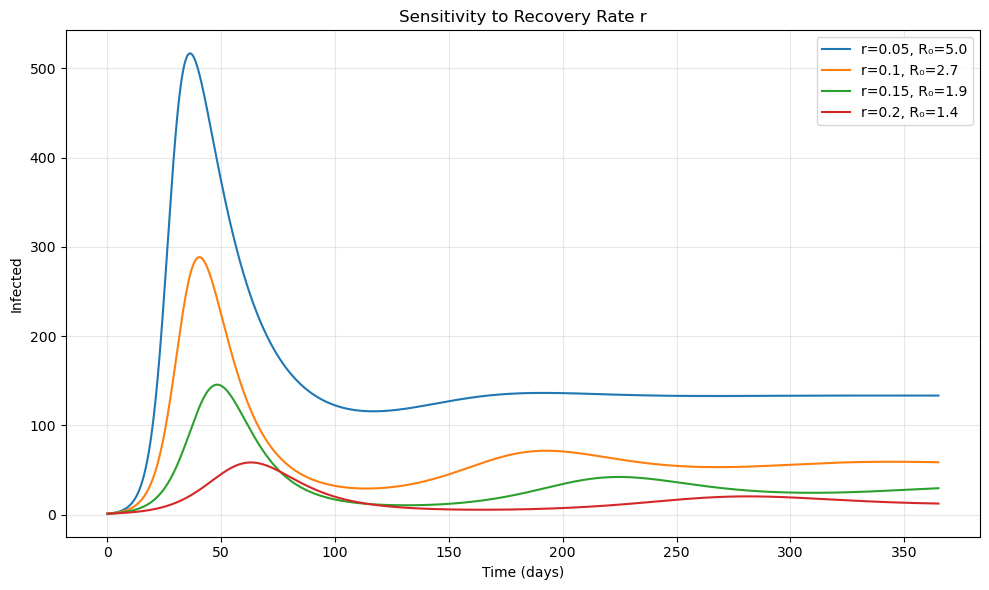

In [15]:
# Sensitivity to recovery rate
recovery_rates = [0.05, 0.1, 0.15, 0.2]

fig, ax = plt.subplots(figsize=(10, 6))

for r in recovery_rates:
    sir = SIR(alpha=0.3, recovery_rate=r, death_rate=0.01)
    method = RK4(sir)
    integrator = Integrator(method, y0, 0, t_max, n_steps)
    dynamics = integrator.integrate()
    t = integrator.get_time()
    
    r0 = sir.basic_reproduction_number()
    ax.plot(t, dynamics[:, 1], label=f'r={r}, R₀={r0:.1f}')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Infected')
ax.set_title('Sensitivity to Recovery Rate r')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

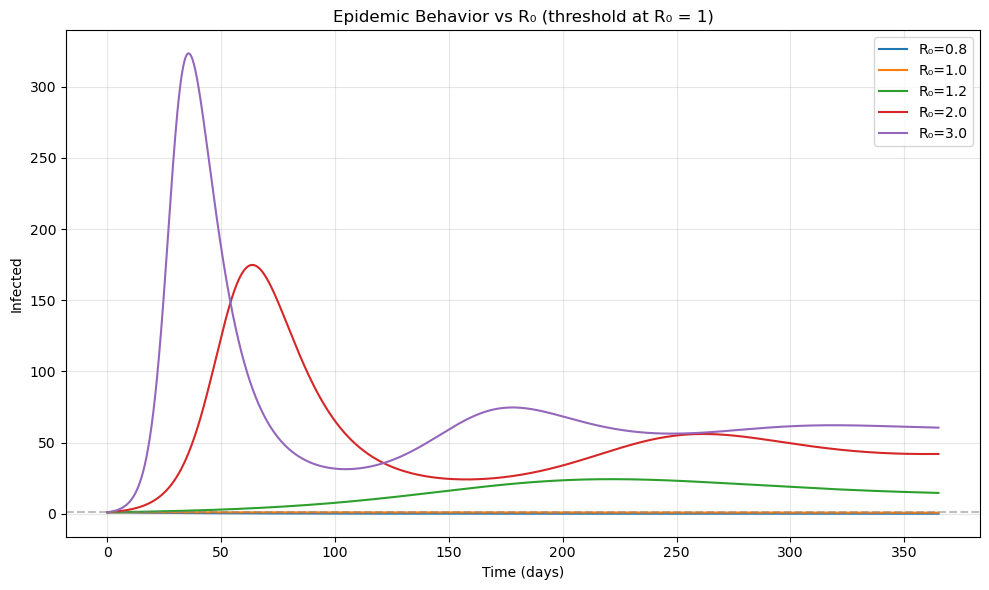

In [16]:
# Demonstrate R₀ threshold behavior
r0_values = [0.8, 1.0, 1.2, 2.0, 3.0]

fig, ax = plt.subplots(figsize=(10, 6))

for r0_target in r0_values:
    # Set alpha to achieve target R₀ with r=0.1, d=0.01
    alpha = r0_target * (0.1 + 0.01)
    sir = SIR(alpha=alpha, recovery_rate=0.1, death_rate=0.01)
    method = RK4(sir)
    integrator = Integrator(method, y0, 0, t_max, n_steps)
    dynamics = integrator.integrate()
    t = integrator.get_time()
    
    ax.plot(t, dynamics[:, 1], label=f'R₀={r0_target}')

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Infected')
ax.set_title('Epidemic Behavior vs R₀ (threshold at R₀ = 1)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()